In [1]:
import numpy as np

from matplotlib import pyplot as plt
%matplotlib inline

from fourier_analysis import Fourier_Analysis


Bad key "text.kerning_factor" on line 4 in
C:\Users\mythk\anaconda3\envs\mir\lib\site-packages\matplotlib\mpl-data\stylelib\_classic_test_patch.mplstyle.
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.1.3/matplotlibrc.template
or from the matplotlib source distribution


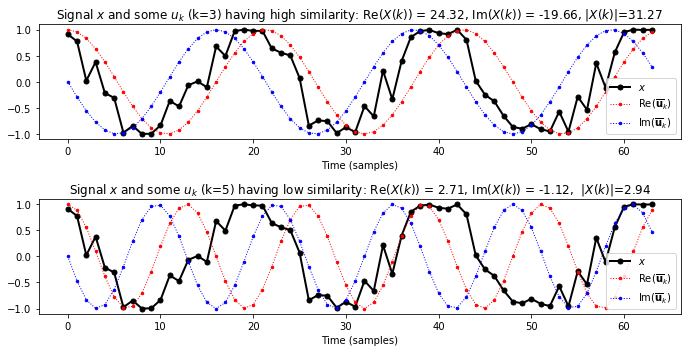

In [2]:
N = 64
n = np.arange(N)
k = 3
x = np.cos(2*np.pi*(k*n/N) + (1.2*np.random.rand(N) - 0.0))

plt.figure(figsize=(10, 5))

plt.subplot(2, 1, 1)
plt.plot(n, x, 'k', marker='.', markersize='10', linewidth=2.0, label='$x$')
plt.xlabel('Time (samples)')
k = 3
u_k_real = np.cos(2*np.pi*k*n/N)
u_k_imag = -np.sin(2*np.pi*k*n/N)
u_k = u_k_real + u_k_imag*1j
sim_complex = np.vdot(u_k, x)
sim_abs = np.abs(sim_complex)
plt.title(r'Signal $x$ and some $u_k$ (k=3) having high similarity: Re($X(k)$) = %0.2f, Im($X(k)$) = %0.2f, $|X(k)|$=%0.2f'%(sim_complex.real, sim_complex.imag, sim_abs))
plt.plot(n, u_k_real, 'r', marker='.', markersize='5', 
         linewidth=1.0, linestyle=':', label='$\mathrm{Re}(\overline{\mathbf{u}}_k)$');
plt.plot(n, u_k_imag, 'b', marker='.', markersize='5', 
         linewidth=1.0, linestyle=':', label='$\mathrm{Im}(\overline{\mathbf{u}}_k)$');
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(n, x, 'k', marker='.', markersize='10', linewidth=2.0, label='$x$')
plt.xlabel('Time (samples)')
k = 5
u_k_real = np.cos(2 * np.pi * k * n / N)
u_k_imag = -np.sin(2 * np.pi * k * n / N)
u_k = u_k_real + u_k_imag*1j
sim_complex = np.vdot(u_k, x)
sim_abs = np.abs(sim_complex)
plt.title(r'Signal $x$ and some $u_k$ (k=5) having low similarity: Re($X(k)$) = %0.2f, Im($X(k)$) = %0.2f,  $|X(k)|$=%0.2f'%(sim_complex.real,sim_complex.imag,sim_abs))
plt.plot(n, u_k_real, 'r', marker='.', markersize='5', 
         linewidth=1.0, linestyle=':', label='$\mathrm{Re}(\overline{\mathbf{u}}_k)$');
plt.plot(n, u_k_imag, 'b', marker='.', markersize='5', 
         linewidth=1.0, linestyle=':', label='$\mathrm{Im}(\overline{\mathbf{u}}_k)$');
plt.legend()

plt.tight_layout()

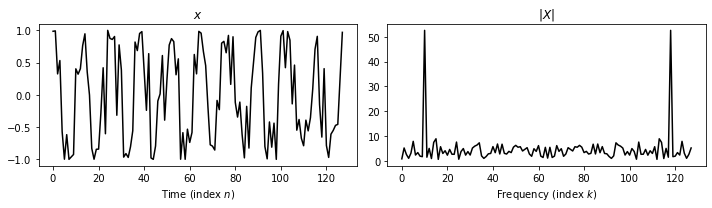

In [3]:
N = 128
n = np.arange(N)
k = 10
x = np.cos(2*np.pi*(k*n/N) + 2*(np.random.rand(N) - 0.5))

fa = Fourier_Analysis(x)
X = fa.dft()

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.title('$x$')
plt.plot(x, 'k')
plt.xlabel('Time (index $n$)')

plt.subplot(1, 2, 2)
plt.title('$|X|$')
plt.plot(np.abs(X), 'k')
plt.xlabel('Frequency (index $k$)')
plt.tight_layout()

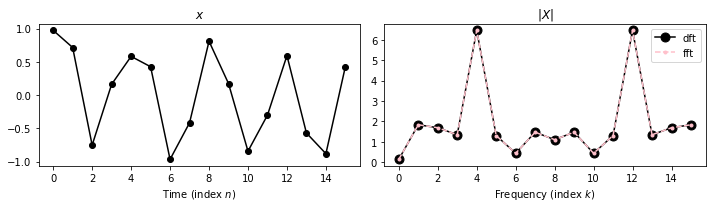

In [4]:
N = 16
n = np.arange(N)
k = 4
x = np.cos(2 * np.pi * (k * n / N) + 2 * (np.random.rand(N) - 0.5)) 

fa = Fourier_Analysis(x)
X_via_dft = fa.dft()
X_via_fft = fa.fft()

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.title('$x$')
plt.plot(x, 'k', marker='.', markersize=12)
plt.xlabel('Time (index $n$)')

plt.subplot(1, 2, 2)
plt.title('$|X|$')
plt.plot(np.abs(X_via_dft), 'k', marker='.', markersize=18, label='dft')
plt.plot(np.abs(X_via_fft), linestyle='--', color='pink', marker='.', markersize=6, label='fft')
plt.xlabel('Frequency (index $k$)')
plt.legend()

plt.tight_layout()

C:\Users\mythk\anaconda3\envs\mir\lib\site-packages\numpy\core\_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


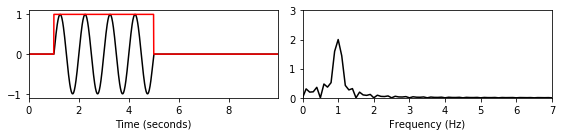

C:\Users\mythk\anaconda3\envs\mir\lib\site-packages\numpy\core\_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


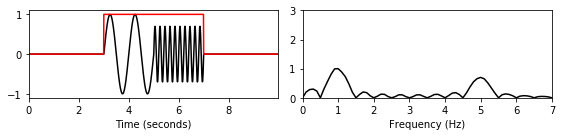

C:\Users\mythk\anaconda3\envs\mir\lib\site-packages\numpy\core\_asarray.py:85: ComplexWarning: Casting complex values to real discards the imaginary part
  return array(a, dtype, copy=False, order=order)


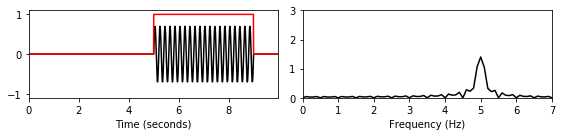

In [5]:
# Generate a chirp-like test signal (details not important)
Fs = 128
duration = 10
omega1 = 1
omega2 = 5
N = int(duration * Fs)
t = np.arange(N) / Fs
t1 = t[:N//2]
t2 = t[N//2:]

x1 = 1.0 * np.sin(2 * np.pi * omega1 * t1)
x2 = 0.7 * np.sin(2 * np.pi * omega2 * t2)
x = np.concatenate((x1, x2))

w_len = 4*Fs

fa = Fourier_Analysis(x)

fa.windowed_ft(t, Fs, w_pos_sec=1, w_len=w_len)
fa.windowed_ft(t, Fs, w_pos_sec=3, w_len=w_len)
fa.windowed_ft(t, Fs, w_pos_sec=5, w_len=w_len)